In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

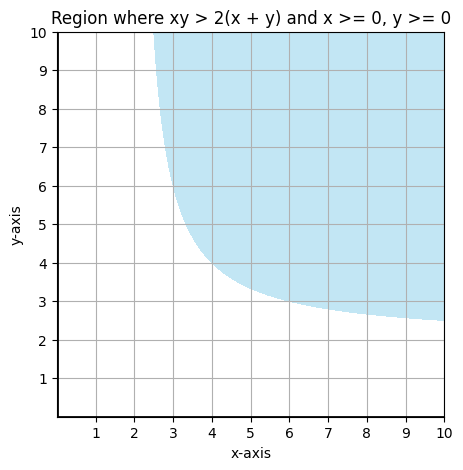

In [2]:
# Define the range for x and y
x = np.linspace(0, 10, 400)
y = np.linspace(0, 10, 400)

# Create a meshgrid for x and y
X, Y = np.meshgrid(x, y)

# Define the inequality xy > 2(x + y)
inequality = X * Y - 2 * (X + Y)

# Plotting the region where the inequality is satisfied
plt.figure(figsize=(5, 5))
plt.contourf(X, Y, inequality, levels=[0, np.inf], colors='skyblue', alpha=0.5)

# Adding labels and title
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Region where xy > 2(x + y) and x >= 0, y >= 0')

# Set custom ticks for x-axis and y-axis
plt.xticks(np.arange(1, 11))
plt.yticks(np.arange(1, 11))

# Show the plot
plt.grid(True)
plt.axhline(0, color='black', lw=2)
plt.axvline(0, color='black', lw=2)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()

In [3]:
def get_cmap_colors(cmap_name, num_colors):
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0, 1, num_colors))
    return colors

cmap_name = 'tab10'
num_colors = 10
# Get a list of colors from the colormap
colors_list_10 = get_cmap_colors(cmap_name, num_colors)
# Convert colors to a list of hex color codes
colors_hex_list_10 = ['#' + ''.join(f'{int(c * 255):02X}' for c in color[:3]) for color in colors_list_10]

In [4]:
def draw_and_save_validation(file_name, measure, output_png):
    # read file
    df = pd.read_csv(file_name)
    df['Precision'] = df['Precision'] / 100
    df['Recall'] = df['Recall'] / 100
    df['F1 Score'] = df['F1'] / 100
    # Categorize data based on the ending of the 'Alignment' strings
    df['Category'] = df['Alignment'].apply(lambda x: 'Without VAL' if x.endswith('component/no_validation') 
                                           else ('With VAL' if x.endswith('component/') 
                                           else 'Unknown'))
    # Colors for each category
    colors = [colors_hex_list_10[0], colors_hex_list_10[1]]
    categories = ['Without VAL', 'With VAL']
    # Calculate positions for each category to place them on the x-axis
    positions = np.arange(1, len(categories) + 1)
    # Adjust jitter for better visibility
    jitter = 0.15
    np.random.seed(42)
    # Marker size
    marker_size = 50
    # Figure size
    fig, ax = plt.subplots(figsize=(2.5, 3))
    
    # Plotting each category with jitter
    for pos, category, color in zip(positions, categories, colors):
        # Extract the precision values for the current category
        precision_values = df[measure][df['Category'] == category].values
        # Apply jitter: randomly adjust the x position slightly to reduce overlap
        jittered_x = pos + np.random.normal(0, jitter, size=len(precision_values))
        ax.scatter(jittered_x, precision_values, color=color, alpha=0.7, label=category, s=marker_size)
        
    # Customizing the plot
    ax.set_title(measure)
    # ax.set_xlabel('Category')
    # ax.set_ylabel(measure)
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_xlim(0.5, len(categories) + 0.5)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # ax.legend()
    
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

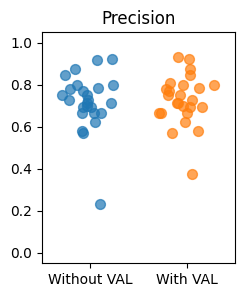

In [5]:
draw_and_save_validation("result-20240331.csv", "Precision", "result_fig/validation-precision.png")

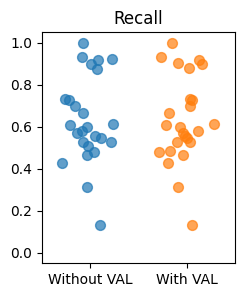

In [6]:
draw_and_save_validation("result-20240331.csv", "Recall", "result_fig/validation-recall.png")

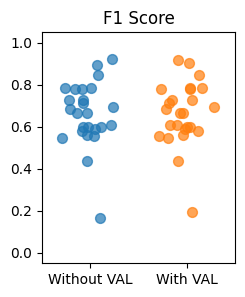

In [7]:
draw_and_save_validation("result-20240331.csv", "F1 Score", "result_fig/validation-f1.png")

In [8]:
def draw_and_save_merge(file_name, measure, output_png):
    # read file
    df = pd.read_csv(file_name)
    df['Precision'] = df['Precision'] / 100
    df['Recall'] = df['Recall'] / 100
    df['F1 Score'] = df['F1'] / 100
    # Categorize data based on the ending of the 'Alignment' strings
    df['Category'] = df['Alignment'].apply(lambda x: '$O_s \Rightarrow O_t$' if x.endswith('source') 
                                           else ('$O_s \Leftarrow O_t$' if x.endswith('target') 
                                           else ('$O_s \Leftrightarrow O_t$' if x.endswith('/') 
                                           else 'Unknown')))
    # Colors for each category
    colors = [colors_hex_list_10[0], colors_hex_list_10[1], colors_hex_list_10[2]]
    categories = ['$O_s \Rightarrow O_t$', '$O_s \Leftarrow O_t$', '$O_s \Leftrightarrow O_t$']
    # Calculate positions for each category to place them on the x-axis
    positions = np.arange(1, len(categories) + 1)
    # Adjust jitter for better visibility
    jitter = 0.15
    np.random.seed(24)
    # Marker size
    marker_size = 50
    # Figure size
    fig, ax = plt.subplots(figsize=(2.5, 3))
    
    # Plotting each category with jitter
    for pos, category, color in zip(positions, categories, colors):
        # Extract the precision values for the current category
        precision_values = df[measure][df['Category'] == category].values
        # Apply jitter: randomly adjust the x position slightly to reduce overlap
        jittered_x = pos + np.random.normal(0, jitter, size=len(precision_values))
        ax.scatter(jittered_x, precision_values, color=color, alpha=0.7, label=category, s=marker_size)
        
    # Customizing the plot
    ax.set_title(measure)
    # ax.set_xlabel('Category')
    # ax.set_ylabel(measure)
    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_xlim(0.5, len(categories) + 0.5)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # ax.legend()
    
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()

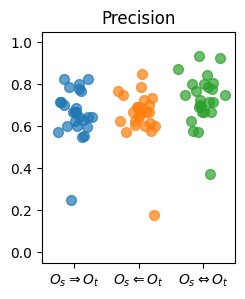

In [9]:
draw_and_save_merge("result-20240331.csv", "Precision", "result_fig/merge-precision.png")

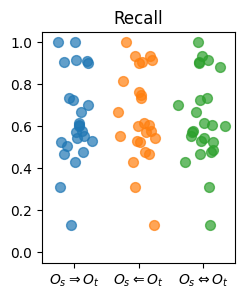

In [10]:
draw_and_save_merge("result-20240331.csv", "Recall", "result_fig/merge-recall.png")

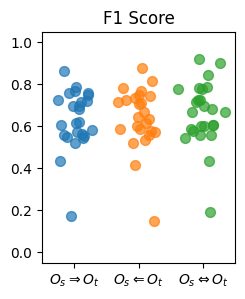

In [11]:
draw_and_save_merge("result-20240331.csv", "F1 Score", "result_fig/merge-f1.png")

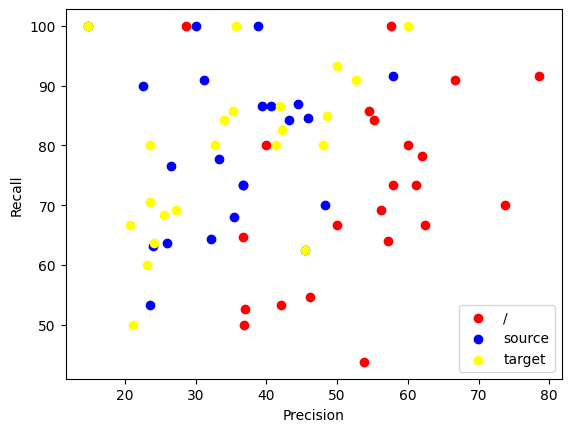

In [12]:
# Assuming 'result.csv' is your file and it's in the current directory
# Replace 'result.csv' with the correct path if your file is located elsewhere
df = pd.read_csv('result-gpt4-0.8.csv')

# Filter rows where column "a" starts with "conference"
filtered_df = df[df['Alignment'].str.startswith("conference")]

# Plotting
fig, ax = plt.subplots()

# Define colors for categories based on the end of strings in column "Alignment"
colors = {"source": "blue", "target": "yellow", "/": "red"}

# Categorize data based on the specific ending of strings in "Alignment"
for key, group in filtered_df.groupby(filtered_df['Alignment'].apply(lambda x: "source" if x.endswith("source") else ("target" if x.endswith("target") else ("/" if x.endswith("/") else "unknown")))):
    color = colors.get(key, "gray")  # Default to gray if the category does not match
    ax.scatter(group["Precision"], group["Recall"], label=key, color=color)

# Setting labels and legend for the plot
ax.set_xlabel("Precision")
ax.set_ylabel("Recall")
ax.legend()

# Show the plot
plt.show()

In [13]:
df = pd.read_csv("result-similarity-cmt-conference.csv")
# Filter rows where the "Alignment" column ends with a number
df = df[df['Alignment'].str.match(r'.*\d$')]
# Extracting decimal numbers from 0.1 to 1.0 in the "Alignment" column
df['Alignment'] = df['Alignment'].str.extract('(0\.[1-9]|1\.0)')
# Converting the "Alignment" column to numeric
df['Alignment'] = pd.to_numeric(df['Alignment'], errors='coerce')
# Sorting the DataFrame by the "Alignment" column in descending order, if needed
df = df.sort_values(by='Alignment', ascending=False)
# set values [0,1]
df['Precision'] = df['Precision'] / 100
df['Recall'] = df['Recall'] / 100
df['F1 Score'] = df['F1'] / 100
# Set 'Alignment' as the index
df.set_index('Alignment', inplace=True)
df

,Precision,Recall,F1,F1 Score
Alignment,,,,
1.0,0.6000,0.2000,30.00,0.3000
0.9,0.4545,0.6667,54.05,0.5405
0.8,0.3333,0.6000,42.86,0.4286
0.7,0.3333,0.6000,42.86,0.4286
0.6,0.3333,0.6000,42.86,0.4286
0.5,0.3462,0.6000,43.90,0.4390
0.4,0.3333,0.6000,42.86,0.4286
0.3,0.3333,0.6000,42.86,0.4286
0.2,0.3333,0.6000,42.86,0.4286


In [14]:
def draw_and_save_similarity(output_png):

    df[['Precision', 'Recall', 'F1 Score']].plot(kind='line', marker='o', 
                                                 figsize=(5, 1.5),color=colors_hex_list_10)
    # plt.figure(figsize=(10, 2))  # Set the figure size (optional)
    # plt.plot(df['Alignment'], df[measure], marker='o', linestyle='-', linewidth=2,
             # color=colors_hex_list_10[color_order])
    
    plt.xlabel('Similarity Threshold')  # x-axis label
    # plt.ylabel(measure)  # y-axis label
    # plt.grid(True)  # Show grid lines

    # Inverting the x-axis to have 1.0 on the left and 0.1 on the right
    plt.gca().invert_xaxis()

    # Setting x-axis ticks to [1.0, 0.9, 0.8, ..., 0.1]
    plt.xticks(np.arange(1.0, 0.0, -0.1), [str(round(x, 1)) for x in np.arange(1.0, 0.0, -0.1)])

    # Setting y-axis ticks to [0.0, 0.2, 0.4, ..., 1.0]
    plt.yticks(np.arange(0.0, 1.1, 0.2))
    
    plt.legend(loc='upper left', bbox_to_anchor=(-0.4, 0.8), frameon=False)
    
    plt.savefig(output_png, bbox_inches='tight', pad_inches=0.1)

    plt.show()  # Display the chart

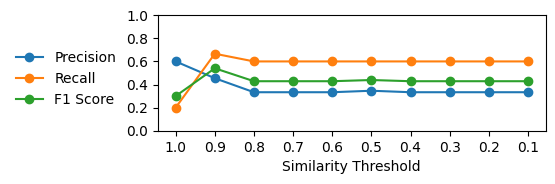

In [15]:
draw_and_save_similarity("result_fig/similarity.png")